In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

# ── Shared style constants ────────────────────────────────────────────────────
C_NM  = "#2F5AA6"   # blue   – net metering
C_NB  = "#7A5195"   # purple – net billing
C_NP  = "#AAAAAA"   # grey   – no PV
C_BAU = "#000000"   # black  – replacement boiler

FIGSIZE  = (10, 3)
SAVE_DPI = 300

LABEL_SIZE  = 8
TICK_SIZE   = 8
LEGEND_SIZE = 7
ANNOT_SIZE  = 8

LINE_KW   = dict(linewidth=1.8)
MARKER_KW = dict(markersize=5, markeredgewidth=0.8, markeredgecolor="black")

# Default values to annotate
DEFAULT_PV_COST   = 2220    # $/kW-DC
DEFAULT_ELEC_ESC  = 6       # %/year
DEFAULT_PROPANE   = 2.01    # $/gallon (shown as $2.00 on axis)


def style_axes(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, fontsize=LABEL_SIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="--", alpha=0.30, zorder=0)
    ax.legend(fontsize=LEGEND_SIZE, frameon=False, handlelength=1.8)


def add_default_vline(ax, x_val, label="Default", ymax_frac=0.92):
    """Draw a vertical dashed line and label indicating the default value."""
    ax.axvline(x_val, color="#888888", linewidth=1.0, linestyle=":", zorder=2)
    ylim = ax.get_ylim()
    y_pos = ylim[0] + ymax_frac * (ylim[1] - ylim[0])
    ax.text(
        x_val, y_pos, f" {label}",
        ha="left", va="top",
        fontsize=LEGEND_SIZE, color="#555555",
        style="italic",
    )


def money(x: float) -> str:
    ax = abs(x)
    if ax >= 1_000_000:
        return f"${x/1_000_000:.2f}M"
    if ax >= 1_000:
        return f"${x/1_000:.0f}k"
    return f"${x:.0f}"

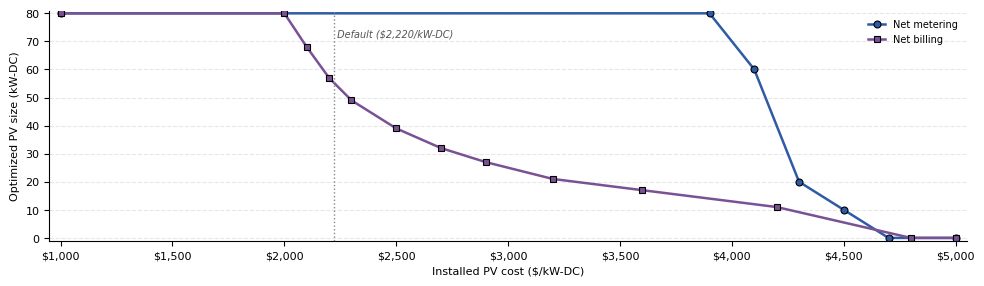

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure I1 – Optimized PV size vs installed PV cost
# Default: $2,220/kW-DC
# ─────────────────────────────────────────────────────────────────────────────
nm_pvcost      = [1000, 3900, 4100, 4300, 4500, 4700, 5000]
nm_pvsize_cost = [  80,   80,   60,   20,   10,    0,    0]

nb_pvcost      = [1000, 2000, 2100, 2200, 2300, 2500, 2700, 2900, 3200, 3600, 4200, 4800, 5000]
nb_pvsize_cost = [  80,   80,   68,   57,   49,   39,   32,   27,   21,   17,   11,    0,    0]

fig, ax = plt.subplots(figsize=FIGSIZE)
fig.patch.set_facecolor("white")
ax.plot(nm_pvcost, nm_pvsize_cost, color=C_NM, marker="o", label="Net metering", **LINE_KW, **MARKER_KW)
ax.plot(nb_pvcost, nb_pvsize_cost, color=C_NB, marker="s", label="Net billing",  **LINE_KW, **MARKER_KW)
ax.set_xlim(950, 5050)
ax.set_ylim(-1, 81)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
style_axes(ax, "Installed PV cost ($/kW-DC)", "Optimized PV size (kW-DC)")
add_default_vline(ax, DEFAULT_PV_COST, label=f"Default (${DEFAULT_PV_COST:,}/kW-DC)")
plt.tight_layout(pad=1.2)
plt.savefig("fig_I1_pv_size_vs_pv_cost.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

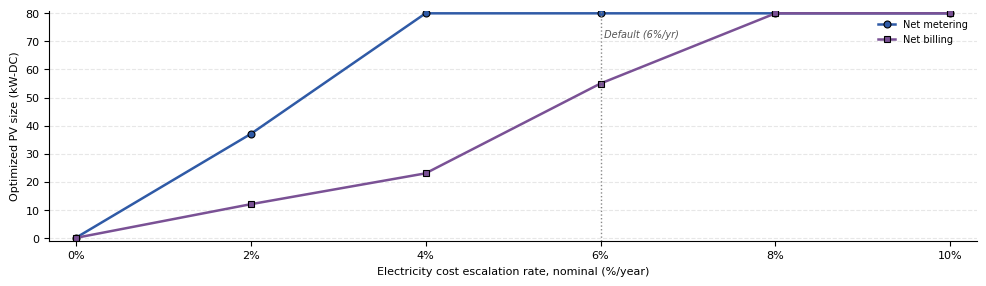

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure I2 – Optimized PV size vs electricity escalation rate
# Default: 6%/year
# ─────────────────────────────────────────────────────────────────────────────
elec_esc      = [ 0,  2,  4,  6,  8, 10]
nm_pvsize_esc = [ 0, 37, 80, 80, 80, 80]
nb_pvsize_esc = [ 0, 12, 23, 55, 80, 80]

fig, ax = plt.subplots(figsize=FIGSIZE)
fig.patch.set_facecolor("white")
ax.plot(elec_esc, nm_pvsize_esc, color=C_NM, marker="o", label="Net metering", **LINE_KW, **MARKER_KW)
ax.plot(elec_esc, nb_pvsize_esc, color=C_NB, marker="s", label="Net billing",  **LINE_KW, **MARKER_KW)
ax.set_xlim(-0.3, 10.3)
ax.set_ylim(-1, 81)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
style_axes(ax, "Electricity cost escalation rate, nominal (%/year)", "Optimized PV size (kW-DC)")
add_default_vline(ax, DEFAULT_ELEC_ESC, label=f"Default ({DEFAULT_ELEC_ESC}%/yr)")
plt.tight_layout(pad=1.2)
plt.savefig("fig_I2_pv_size_vs_elec_esc.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

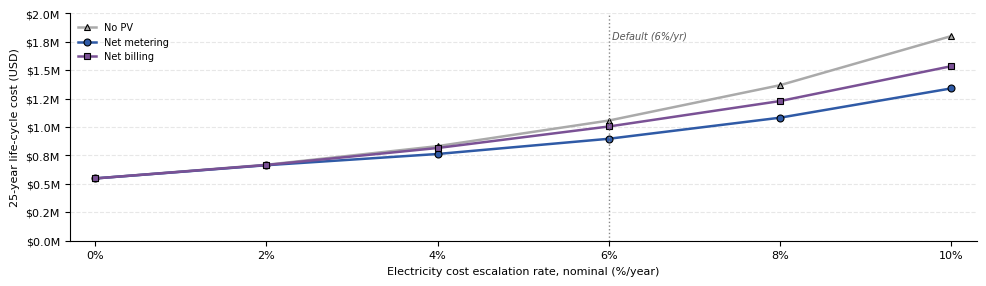

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure I3 – 25-year life-cycle cost vs electricity escalation rate
# Default: 6%/year
# ─────────────────────────────────────────────────────────────────────────────
lcc_nopv = [548012,  668078,  831833, 1056792, 1367627, 1799043]
lcc_nm   = [548012,  664124,  762918,  896695, 1081906, 1339423]
lcc_nb   = [548012,  666059,  815545, 1004691, 1228116, 1534534]

fig, ax = plt.subplots(figsize=FIGSIZE)
fig.patch.set_facecolor("white")
ax.plot(elec_esc, [v/1e6 for v in lcc_nopv], color=C_NP,  marker="^", label="No PV",        **LINE_KW, **MARKER_KW)
ax.plot(elec_esc, [v/1e6 for v in lcc_nm],   color=C_NM,  marker="o", label="Net metering", **LINE_KW, **MARKER_KW)
ax.plot(elec_esc, [v/1e6 for v in lcc_nb],   color=C_NB,  marker="s", label="Net billing",  **LINE_KW, **MARKER_KW)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:.1f}M"))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_xlim(-0.3, 10.3)
ax.set_ylim(0, 2.0)
style_axes(ax, "Electricity cost escalation rate, nominal (%/year)", "25-year life-cycle cost (USD)")
add_default_vline(ax, DEFAULT_ELEC_ESC, label=f"Default ({DEFAULT_ELEC_ESC}%/yr)")
plt.tight_layout(pad=1.2)
plt.savefig("fig_I3_lcc_vs_elec_esc.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

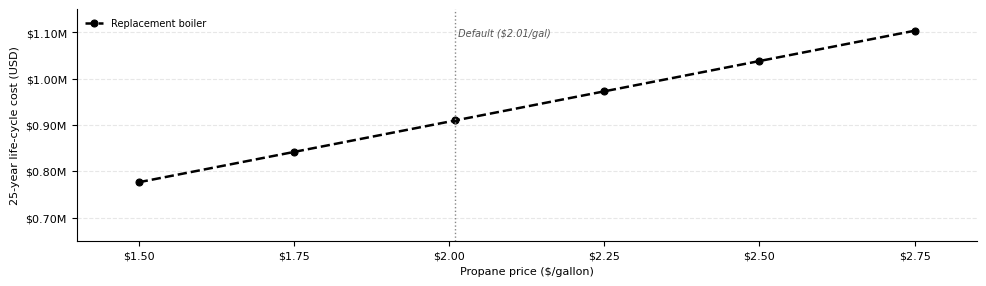

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure I4 – 25-year life-cycle cost vs propane price
# Default: $2.01/gallon (shown as $2.00 on axis tick, vline at 2.01)
# ─────────────────────────────────────────────────────────────────────────────
propane_price = [1.50,   1.75,   2.01,   2.25,   2.50,   2.75  ]
bau_lcc       = [776333, 841816, 909918, 972781, 1038264, 1103746]

# Axis tick labels: show $2.01 as $2.00
tick_labels = [f"${p:.2f}" if p != 2.01 else "$2.00" for p in propane_price]

fig, ax = plt.subplots(figsize=FIGSIZE)
fig.patch.set_facecolor("white")
ax.plot(
    propane_price, [v/1e6 for v in bau_lcc],
    color=C_BAU, linestyle="--", marker="o",
    label="Replacement boiler",
    **LINE_KW, **MARKER_KW,
)
ax.set_xticks([1.50,   1.75,   2.00,   2.25,   2.50,   2.75  ])
ax.set_xticklabels(tick_labels)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:.2f}M"))
ax.set_xlim(1.40, 2.85)
ax.set_ylim(0.65, 1.15)
style_axes(ax, "Propane price ($/gallon)", "25-year life-cycle cost (USD)")
add_default_vline(ax, DEFAULT_PROPANE, label="Default ($2.01/gal)")
plt.tight_layout(pad=1.2)
plt.savefig("fig_I4_lcc_vs_propane.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()